# CLIMADA CE

## Takeaways:

* Loading compressed data can be faster if the data is much smaller on disk
* Reprojection is expensive. If CRS as the same, better interpolate or even better regrid
* Rechunking does not seem too helpful. But may reduce graph size!
* Excluding NaNs from the calculation apparently takes longer! Numpy seems to fast-pace NaNs, or `where` is expensive, even with funcs.
* `resample_like` can also resample time, careful!
* ZARR is much faster than NetCDF

In [1]:
import xarray as xr
from dask.distributed import Client
import odc.geo.xr  # noqa: F401
import numpy as np

# Exposure data array
exposure = xr.open_dataarray(
    "data/exposure/deu_ppp_2000_UNadj.tif",
    chunks="auto",
    decode_coords="all",
    engine="rasterio",
)
exposure = exposure.squeeze(drop=True)
# exposure = exposure.rename({"x": "longitude", "y": "latitude"})
# exposure = exposure.odc.reproject("EPSG:3577", dst_nodata=np.nan)

exposure

<xarray.DataArray 'band_data' (y: 9345, x: 10999)> Size: 411MB
dask.array<getitem, shape=(9345, 10999), dtype=float32, chunksize=(2560, 10999), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y            (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area

In [2]:
exposure.spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 8B
[1 values with dtype=int64]
Coordinates:
    spatial_ref  int64 8B ...
Attributes:
    crs_wkt:                      GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    semi_major_axis:              6378137.0
    semi_minor_axis:              6356752.314245179
    inverse_flattening:           298.257223563
    reference_ellipsoid_name:     WGS 84
    longitude_of_prime_meridian:  0.0
    prime_meridian_name:          Greenwich
    geographic_crs_name:          WGS 84
    horizontal_datum_name:        World Geodetic System 1984
    grid_mapping_name:            latitude_longitude
    spatial_ref:                  GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    GeoTransform:                 5.872083325 0.0008333333300300026 0.0 55.05...

In [3]:
exposure.odc.spatial_dims

('y', 'x')

In [4]:
exposure.rio.x_dim, exposure.rio.y_dim

('x', 'y')

In [5]:
# Exposure dataset with multiple arrays
exposure = xr.Dataset(
    {
        "2000": xr.open_dataarray(
            "data/exposure/deu_ppp_2000_1km_Aggregated_UNadj.tif",
            chunks="auto",
            decode_coords="all",
            engine="rasterio",
        ),
        "2001": xr.open_dataarray(
            "data/exposure/deu_ppp_2001_1km_Aggregated_UNadj.tif",
            chunks="auto",
            decode_coords="all",
            engine="rasterio",
        ),
    }
)
exposure = exposure.squeeze(drop=True)
# exposure = exposure.rename({"x": "longitude", "y": "latitude"})
exposure

<xarray.Dataset> Size: 8MB
Dimensions:      (x: 1100, y: 934)
Coordinates:
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B 0
Data variables:
    2000         (y, x) float32 4MB dask.array<chunksize=(934, 1100), meta=np.ndarray>
    2001         (y, x) float32 4MB dask.array<chunksize=(934, 1100), meta=np.ndarray>

In [6]:
import pandas as pd

# Single exposure array with time axis
exposure = xr.concat(
        [xr.open_dataarray(
            "data/exposure/deu_ppp_2000_UNadj.tif",
            chunks="auto",
            decode_coords="all",
            engine="rasterio",
        ),
        xr.open_dataarray(
            "data/exposure/deu_ppp_2001_UNadj.tif",
            chunks="auto",
            decode_coords="all",
            engine="rasterio",
        ),], dim=pd.DatetimeIndex(["2021-06-12", "2021-06-15"], name="time")
)
exposure = exposure.squeeze(drop=True)
# exposure = exposure.rename({"x": "longitude", "y": "latitude"})
exposure

<xarray.DataArray 'band_data' (time: 2, y: 9345, x: 10999)> Size: 822MB
dask.array<getitem, shape=(2, 9345, 10999), dtype=float32, chunksize=(1, 2560, 10999), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 88kB 5.872 5.873 5.874 5.875 ... 15.04 15.04 15.04
  * y            (y) float64 75kB 55.06 55.06 55.05 55.05 ... 47.27 47.27 47.27
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 16B 2021-06-12 2021-06-15
Attributes:
    AREA_OR_POINT:  Area

In [7]:
exposure.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

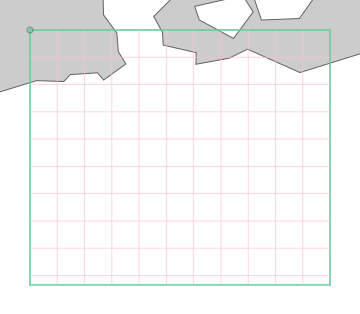

In [8]:
exposure.odc.geobox

In [31]:
exposure.chunksizes

Frozen({'time': (1, 1), 'y': (2560, 2560, 2560, 1665), 'x': (10999,)})

In [10]:
def norm_chunks(chunksizes, agg):
    return {dim: agg(chunks) for dim, chunks in chunksizes.items()}

In [ ]:
hazard = xr.open_dataset(
    "data/hazard/flood-2021-06-fine.nc", chunks="auto", decode_coords="all"
)["flood_depth"]
# hazard = hazard.isel(number=1, step=1)
# hazard = hazard.unify_chunks()
# hazard = hazard.chunk(longitude=2000, latitude=2000)
# hazard = hazard.chunk(norm_chunks(exposure.chunksizes, lambda x: int(np.max(x))))
hazard = hazard.unify_chunks()
hazard = hazard.chunk(norm_chunks(hazard.chunksizes, lambda x: int(np.max(x))))
hazard = hazard.unify_chunks()
hazard

<xarray.DataArray 'flood_depth' (latitude: 1859, longitude: 2183, number: 10,
                                 time: 3, step: 5)> Size: 2GB
dask.array<open_dataset-flood_depth, shape=(1859, 2183, 10, 3, 5), dtype=float32, chunksize=(620, 728, 4, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
  * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 120B dask.array<chunksize=(3, 5), meta=np.ndarray>
  * longitude   (longitude) float64 17kB 5.878 5.883 5.887 ... 14.96 14.97 14.97
  * latitude    (latitude) float64 15kB 55.02 55.02 55.01 ... 47.29 47.28 47.28

In [12]:
import odc.geo.xr  # noqa: F401

# Resampling
hazard = hazard.odc.assign_crs("EPSG:4326")

hazard.rio.crs == exposure.rio.crs

True

In [13]:
hazard["spatial_ref"]

<xarray.DataArray 'spatial_ref' ()> Size: 4B
array(4326, dtype=int32)
Coordinates:
    surface      float64 8B ...
    spatial_ref  int32 4B 4326
Attributes:
    spatial_ref:                  GEOGCRS["WGS 84",ENSEMBLE["World Geodetic S...
    crs_wkt:                      GEOGCRS["WGS 84",ENSEMBLE["World Geodetic S...
    semi_major_axis:              6378137.0
    semi_minor_axis:              6356752.314245179
    inverse_flattening:           298.257223563
    reference_ellipsoid_name:     WGS 84
    longitude_of_prime_meridian:  0.0
    prime_meridian_name:          Greenwich
    geographic_crs_name:          WGS 84
    horizontal_datum_name:        World Geodetic System 1984 ensemble
    grid_mapping_name:            latitude_longitude

In [14]:
hazard.rio.x_dim, hazard.rio.y_dim

('longitude', 'latitude')

In [ ]:
hazard.chunksizes

In [ ]:
from dask.distributed import Client

hazard = hazard.odc.reproject(exposure.odc.geobox, dst_nodata=np.nan)
hazard = hazard.sel(time=exposure["time"])
arr_name = hazard.name

# Simple reindexing
# hazard = hazard.reindex_like(exposure, method="nearest", tolerance=0.01)

# Subselection
# hazard = hazard.sel(time="2021-06-12").isel(step=0)
with Client(n_workers=1, threads_per_worker=4, memory_limit="4GB"):
    hazard.to_zarr("data/output/hazard.zarr", mode="w")

del hazard

ValueError: Final chunk of Zarr array must be the same size or smaller than the first. Variable named 'reproject-18f2b6a437b244c9944a108ca9d87fdf' has incompatible Dask chunks ((620, 620, 620, 620, 620, 620, 620, 620, 620, 620, 620, 620, 620, 620, 620, 45), (728, 728, 728, 728, 728, 728, 728, 728, 728, 728, 728, 728, 728, 728, 728, 79), (3, 3, 4), (1, 1), (1, 1, 1, 1, 1)).Consider either rechunking using `chunk()` or instead deleting or modifying `encoding['chunks']`.

In [ ]:
hazard = xr.open_dataset("data/output/hazard.zarr", chunks="auto")[arr_name]
hazard

/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'netcdf4' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)
/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/xarray/backends/api.py:651: RuntimeWarning: 'scipy' fails while guessing
  engine = plugins.guess_engine(filename_or_obj)


<xarray.DataArray 'reproject-dcdf8cfb3ffb4e2fad6eca0c9c811292' (latitude: 9345,
                                                                longitude: 10999,
                                                                number: 10,
                                                                time: 2, step: 5)> Size: 41GB
dask.array<open_dataset-reproject-dcdf8cfb3ffb4e2fad6eca0c9c811292, shape=(9345, 10999, 10, 2, 5), dtype=float32, chunksize=(1909, 2267, 4, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * latitude    (latitude) float64 75kB 55.06 55.06 55.05 ... 47.27 47.27 47.27
  * longitude   (longitude) float64 88kB 5.872 5.873 5.874 ... 15.04 15.04 15.04
  * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
    surface     float64 8B ...
  * time        (time) datetime64[ns] 16B 2021-06-12 2021-06-15
    valid_time  (time, step) datetime64[ns] 80B dask.array<chunksize=(2, 5), meta=np.ndarray>
Attributes:
    grid_mapping:  spatial_ref

In [ ]:
# from rechunker import rechunk

# arr_plan = rechunk(
#     hazard.to_dataset(),
#     target_chunks=norm_chunks(exposure.chunksizes, np.min),
#     target_store="data/rechunked.zarr",
#     max_mem="4G",
# )
# hazard = arr_plan.execute()



# hazard

In [ ]:
# import sparse

# hazard = xr.apply_ufunc(
#     sparse.COO.from_numpy,
#     hazard,
#     dask="parallelized",
#     output_dtypes=[hazard.dtype],
# )
# hazard

In [ ]:
# hazard, exposure = xr.unify_chunks(hazard, exposure)
# hazard, exposure

In [ ]:
import numpy as np


def impact_func(intensity, threshold, half_point, exponent, scale):
    luk = (intensity - threshold) / (half_point - threshold)
    # luk = np.where(luk < 0, 0, luk)
    return scale * luk**exponent / (1 + luk**exponent)

In [ ]:
from functools import partial

impf = partial(impact_func, threshold=0.1, half_point=1.0, scale=1.0, exponent=3)
x = np.linspace(0, 10, 100)
y = impf(x)


def impf_interp(intensity):
    return np.interp(intensity, x, y)


# impact = exposure * hazard.where(np.isnan, impf)
impact = exposure * impf(hazard)

if isinstance(impact, xr.DataArray):
    impact = impact.to_dataset(name="impact")
impact

<xarray.Dataset> Size: 41GB
Dimensions:      (longitude: 10999, latitude: 9345, time: 2, number: 10, step: 5)
Coordinates:
  * longitude    (longitude) float64 88kB 5.872 5.873 5.874 ... 15.04 15.04
  * latitude     (latitude) float64 75kB 55.06 55.06 55.05 ... 47.27 47.27 47.27
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 16B 2021-06-12 2021-06-15
  * number       (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * step         (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
    surface      float64 8B 0.0
    valid_time   (time, step) datetime64[ns] 80B dask.array<chunksize=(2, 5), meta=np.ndarray>
Data variables:
    impact       (time, latitude, longitude, number, step) float32 41GB dask.array<chunksize=(1, 1859, 2183, 4, 1), meta=np.ndarray>

In [ ]:
# impact = impact.unify_chunks()
impact = impact.unify_chunks()
impact = impact.chunk(norm_chunks(impact.chunksizes, lambda x: int(np.max(x))))
impact.chunksizes

Frozen({'time': (1, 1), 'step': (1, 1, 1, 1, 1), 'latitude': (1859, 1859, 1859, 1859, 1859, 50), 'longitude': (2267, 2267, 2267, 2267, 1931), 'number': (4, 4, 2)})

In [ ]:
from dask.distributed import Client
from climada_petals.hazard.rf_glofas import save_file

with Client(n_workers=1, threads_per_worker=4, memory_limit="4GB"):
    impact.to_zarr("data/output/flood.zarr", mode="w")
    # save_file(
    #     # impact.to_dataset(name="impact"),
    #     impact,
    #     "data/output/flood-2021-06.nc",
    #     zlib=False,
    #     complevel=1,
    # )

In [ ]:
impact["2000"].to_dataset().data_vars.keys()

KeyError: "No variable named '2000'. Variables on the dataset include ['longitude', 'latitude', 'spatial_ref', 'time', 'number', 'step', 'surface', 'valid_time', 'impact']"

In [ ]:
enc = {"dtype": "float32", "zlib": True, "complevel": 1}
delayed = xr.save_mfdataset(
        [impact["2000"].to_dataset(), impact["2001"].to_dataset()],
        ["data/output/flood-2000.nc", "data/output/flood-2001.nc"],
        compute=False
        # encoding={"2000": enc, "2001": enc},
    )
with Client(n_workers=2, threads_per_worker=2, memory_limit="2GB"):
    delayed.compute()

--- Logging error ---
Traceback (most recent call last):
  File "/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/distributed/protocol/pickle.py", line 60, in dumps
    result = pickle.dumps(x, **dump_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: cannot pickle '_thread.lock' object

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/distributed/protocol/pickle.py", line 65, in dumps
    pickler.dump(x)
TypeError: cannot pickle '_thread.lock' object

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/distributed/protocol/pickle.py", line 77, in dumps
    result = cloudpickle.dumps(x, **dump_kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/l

TypeError: Could not serialize object of type _HLGExprSequence